# ChurnSight : SHAP Explainability

**Why SHAP matters:**
A model that says 'this customer will churn' is useless without 'because of X, Y, Z'.
Retention teams need to know WHY so they can act — offer a discount? Upgrade their plan? Assign a support rep?

**Part 3 :** SHAP (**SH**apley **A**dditive ex**P**lanations) answers:
- Globally: which features drive churn across all customers?
- Locally: why did the model flag THIS specific customer?

(This notebook produces 4 plots used directly in the Streamlit dashboard.)

In [1]:
#%pip install "numpy<2.0.0" --force-reinstall
#%pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print('SHAP version:', shap.__version__)
print('Install if missing: pip install shap')

SHAP version: 0.49.1
Install if missing: pip install shap


In [3]:
# Load model and test data
with open('../models/xgboost_model.pkl', 'rb') as f:
    artifacts = pickle.load(f)

model     = artifacts['xgb_model']
threshold = artifacts['optimal_threshold']
features  = artifacts['feature_names']

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f'Test set: {X_test.shape}')
print(f'Optimal threshold: {threshold:.2f}')

Test set: (1409, 36)
Optimal threshold: 0.45


In [4]:
#%pip install "xgboost<3.0.0"

## Step 1 : Compute SHAP Values

TreeExplainer is the fastest and most accurate SHAP method for tree-based models like XGBoost.
It computes exact SHAP values (not approximations) using the tree structure.

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value (base rate): {explainer.expected_value:.4f}')
# Expected value = average model output across all predictions
# Each SHAP value = how much that feature pushed the prediction UP or DOWN from this base

SHAP values shape: (1409, 36)
Expected value (base rate): 0.0037


## Plot 1 : Global Feature Importance (Mean |SHAP|)

Shows which features matter most ACROSS ALL customers.
This is your headline number - 'tenure is the #1 driver of churn in our model'.

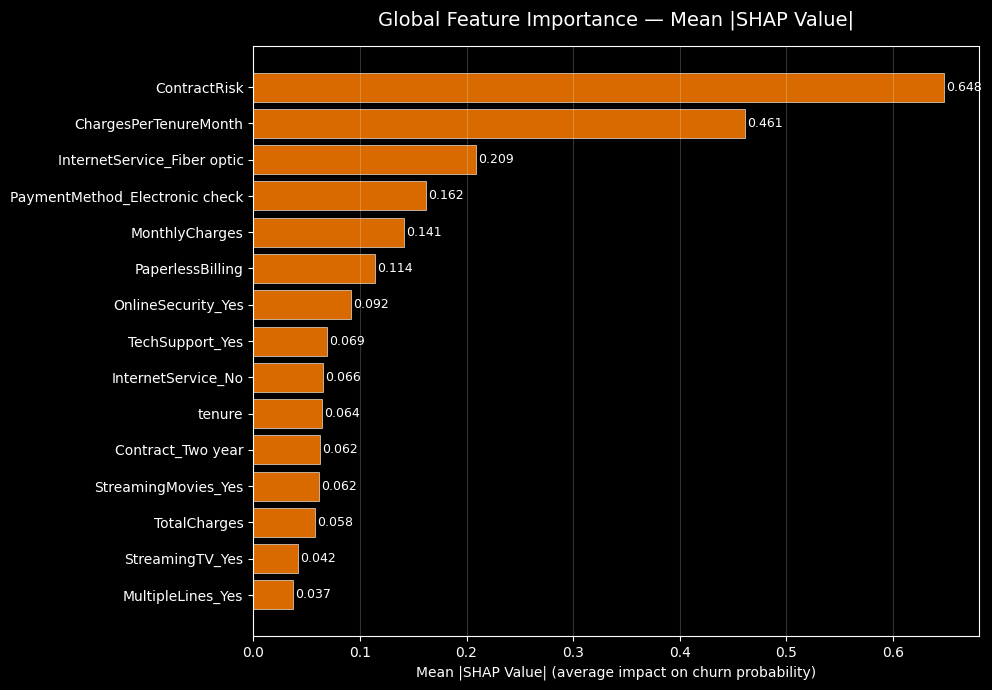

Top 5 churn drivers:
                       feature  importance
                  ContractRisk    0.648013
         ChargesPerTenureMonth    0.461484
   InternetService_Fiber optic    0.209201
PaymentMethod_Electronic check    0.162187
                MonthlyCharges    0.141329


In [6]:
# Mean absolute SHAP value per feature = global importance
mean_abs_shap = pd.DataFrame({
    'feature': features,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    mean_abs_shap['feature'][::-1],
    mean_abs_shap['importance'][::-1],
    color='#ff7e00', alpha=0.85, edgecolor='white', linewidth=0.5
)
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

ax.set_title('Global Feature Importance — Mean |SHAP Value|', fontsize=14, pad=15)
ax.set_xlabel('Mean |SHAP Value| (average impact on churn probability)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('../assets/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 churn drivers:')
print(mean_abs_shap.head(5).to_string(index=False))

## Plot 2 : SHAP Beeswarm (Summary Plot)

The most information-dense SHAP plot. Shows:
- Which features matter most (y-axis order)
- Direction of effect (positive SHAP = increases churn probability)
- Feature value (color: red=high, blue=low)

Example reading: 'High tenure (red) has negative SHAP = reduces churn. Low tenure (blue) has positive SHAP = increases churn.'

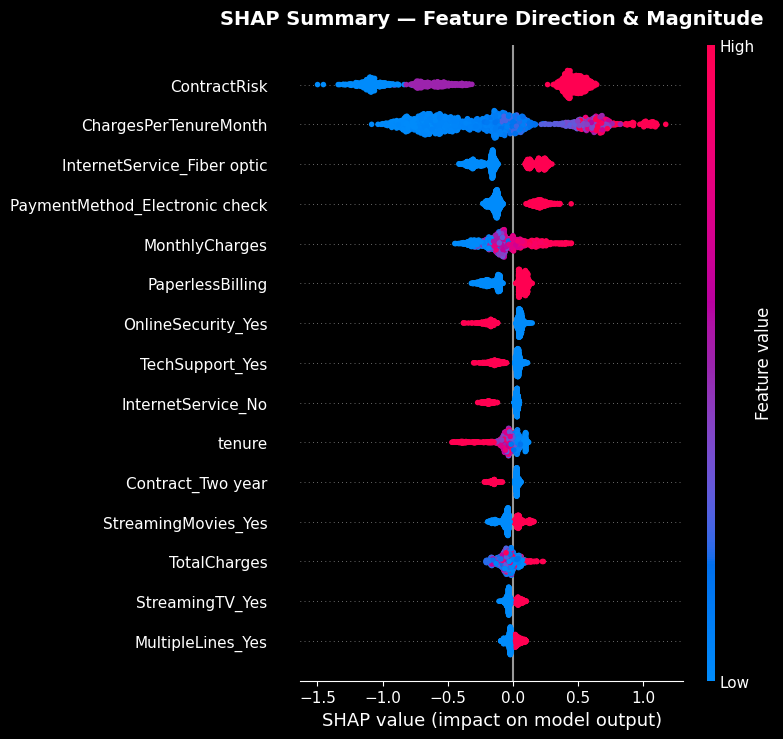

In [14]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False,
    plot_type='dot'
)

# Fix dark mode visibility by setting all text elements to white
for ax in plt.gcf().axes:
    ax.tick_params(colors='white', labelsize=11)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.title('SHAP Summary — Feature Direction & Magnitude', fontsize=14, pad=15, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 3 : SHAP Dependence Plot

Shows how one specific feature's value affects the churn prediction.
We do this for the top 2 features — typically tenure and MonthlyCharges.

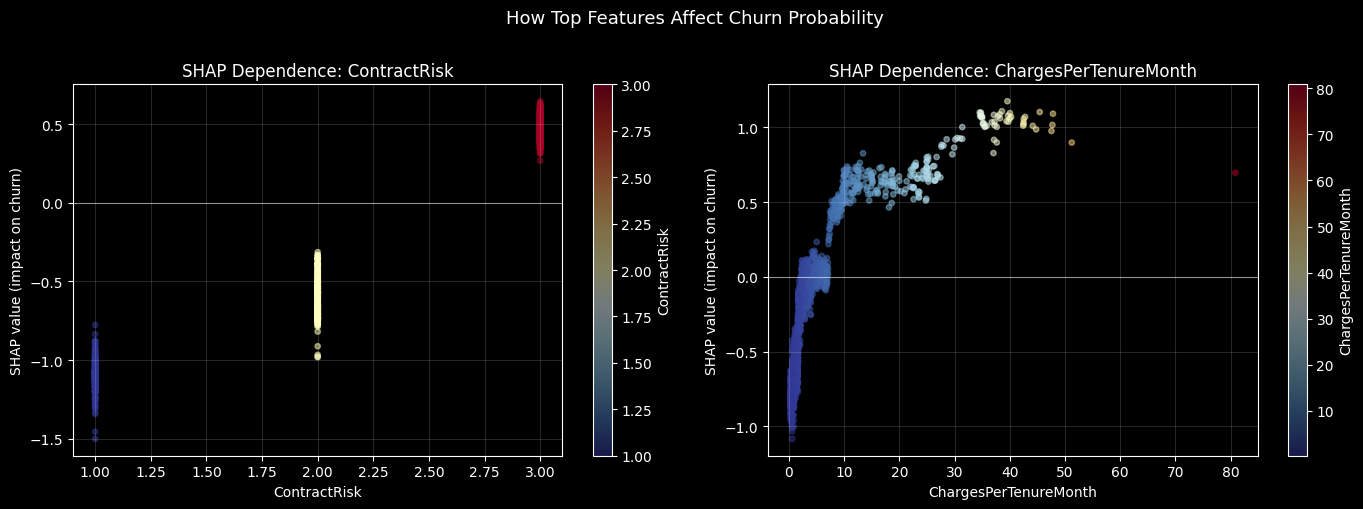

In [8]:
top2_features = mean_abs_shap['feature'].iloc[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, top2_features):
    feat_idx = features.index(feat)
    x_vals   = X_test[feat].values
    y_vals   = shap_values[:, feat_idx]

    sc = ax.scatter(x_vals, y_vals, c=x_vals, cmap='RdYlBu_r', alpha=0.5, s=15)
    ax.axhline(y=0, color='white', linewidth=0.8, alpha=0.5)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value (impact on churn)')
    plt.colorbar(sc, ax=ax, label=feat)
    ax.grid(alpha=0.15)

plt.suptitle('How Top Features Affect Churn Probability', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../assets/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 : Local Explanation (Individual Customer)

This is what the Streamlit app will generate for each prediction.
Pick a customer predicted to churn and explain exactly why.

In [9]:
# Find a high-confidence churn prediction for a clear example
xgb_proba = model.predict_proba(X_test)[:, 1]
high_churn_idx = np.argsort(xgb_proba)[::-1][:20]  # top 20 most likely to churn

# Pick index 0 for the demo (highest probability churner)
CUSTOMER_IDX = high_churn_idx[0]
customer_prob = xgb_proba[CUSTOMER_IDX]
customer_actual = y_test.iloc[CUSTOMER_IDX]

print(f'Customer #{CUSTOMER_IDX}')
print(f'Predicted churn probability: {customer_prob:.1%}')
print(f'Actual outcome: {"Churned" if customer_actual == 1 else "Stayed"}')
print(f'\nTop features for this customer:')
customer_shap = pd.DataFrame({
    'feature': features,
    'shap_value': shap_values[CUSTOMER_IDX],
    'feature_value': X_test.iloc[CUSTOMER_IDX].values
}).sort_values('shap_value', key=abs, ascending=False).head(10)
print(customer_shap.to_string(index=False))

Customer #1109
Predicted churn probability: 93.7%
Actual outcome: Churned

Top features for this customer:
                       feature  shap_value feature_value
         ChargesPerTenureMonth    1.057357        42.525
                  ContractRisk    0.584641             3
   InternetService_Fiber optic    0.201521          True
PaymentMethod_Electronic check    0.157615          True
                        tenure    0.101387             1
              PaperlessBilling    0.090449             1
             MultipleLines_Yes    0.085756          True
                MonthlyCharges    0.073733         85.05
            OnlineSecurity_Yes    0.064072         False
                 SeniorCitizen    0.053104             1


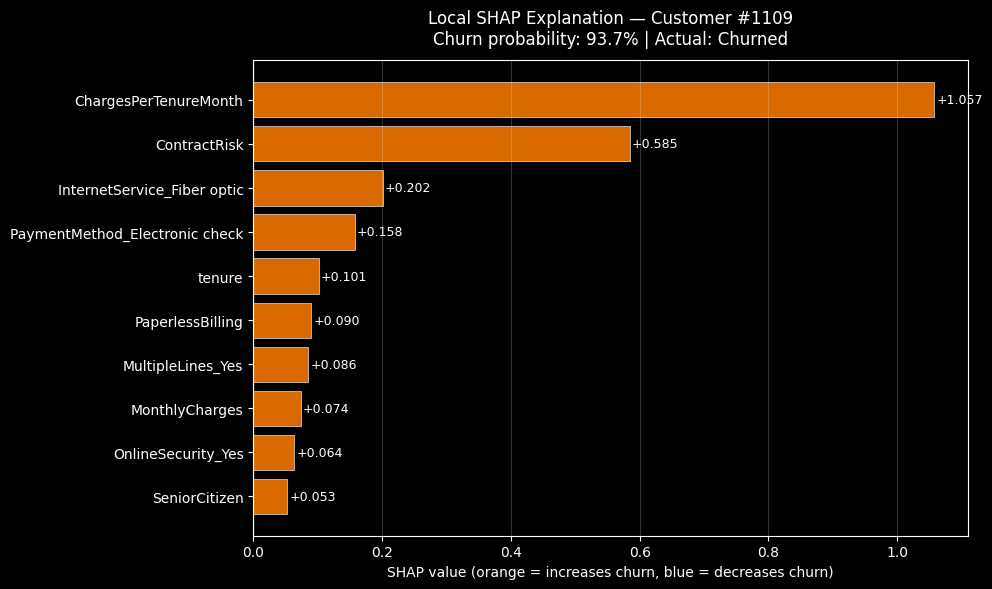

In [10]:
# Waterfall-style local explanation (custom — works better with dark theme than shap.plots.waterfall)
top_n = 10
local_shap = shap_values[CUSTOMER_IDX]
local_df = pd.DataFrame({'feature': features, 'shap': local_shap})
local_df = local_df.reindex(local_df['shap'].abs().sort_values(ascending=False).index).head(top_n)
local_df = local_df.sort_values('shap')

colors = ['#00b4d8' if v < 0 else '#ff7e00' for v in local_df['shap']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(local_df['feature'], local_df['shap'], color=colors, alpha=0.85, edgecolor='white', lw=0.5)
ax.axvline(x=0, color='white', linewidth=0.8)

for bar, val in zip(bars, local_df['shap']):
    x_pos = val + (0.003 if val >= 0 else -0.003)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9)

ax.set_title(
    f'Local SHAP Explanation — Customer #{CUSTOMER_IDX}\n'
    f'Churn probability: {customer_prob:.1%} | Actual: {"Churned" if customer_actual==1 else "Stayed"}',
    fontsize=12, pad=12
)
ax.set_xlabel('SHAP value (orange = increases churn, blue = decreases churn)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('../assets/shap_local_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Segment Analysis

Combine model predictions with SHAP to find which customer segments to prioritize.
This is the 'business framing' that turns a model into a strategy.

In [11]:
# Build a results dataframe with predictions + top SHAP driver per customer
results = X_test.copy()
results['churn_probability'] = xgb_proba
results['predicted_churn']   = (xgb_proba >= threshold).astype(int)
results['actual_churn']      = y_test.values
results['top_driver']        = [
    features[np.argmax(np.abs(shap_values[i]))]
    for i in range(len(X_test))
]

# Risk tiers based on probability
def risk_tier(p):
    if p >= 0.75: return 'Critical (>75%)'
    elif p >= 0.50: return 'High (50-75%)'
    elif p >= 0.30: return 'Medium (30-50%)'
    else: return 'Low (<30%)'

results['risk_tier'] = results['churn_probability'].apply(risk_tier)

# Segment summary
tier_summary = results.groupby('risk_tier').agg(
    customers=('churn_probability', 'count'),
    avg_prob=('churn_probability', 'mean'),
    actual_churn_rate=('actual_churn', 'mean')
).round(3)
print('Risk Tier Summary:')
print(tier_summary)

# Top churn drivers across flagged customers
flagged = results[results['predicted_churn'] == 1]
print(f'\nTop churn drivers among {len(flagged)} flagged customers:')
print(flagged['top_driver'].value_counts().head(5))

Risk Tier Summary:
                 customers  avg_prob  actual_churn_rate
risk_tier                                              
Critical (>75%)        254     0.832              0.673
High (50-75%)          315     0.636              0.406
Low (<30%)             620     0.128              0.055
Medium (30-50%)        220     0.398              0.186

Top churn drivers among 622 flagged customers:
top_driver
ContractRisk                   345
ChargesPerTenureMonth          275
InternetService_Fiber optic      2
Name: count, dtype: int64


In [13]:
# Save results with SHAP drivers for Streamlit app
results.to_csv('../data/predictions_with_shap.csv', index=False)

# Save SHAP values array for the app
import numpy as np
np.save('../models/shap_values_test.npy', shap_values)

print('Saved: data/predictions_with_shap.csv')
print('Saved: models/shap_values_test.npy')
print('\n=== Part 3 Complete ===')
print('Assets created: shap_global_importance.png, shap_beeswarm.png,')
print('                shap_dependence.png, shap_local_explanation.png')

Saved: data/predictions_with_shap.csv
Saved: models/shap_values_test.npy

=== Part 3 Complete ===
Assets created: shap_global_importance.png, shap_beeswarm.png,
                shap_dependence.png, shap_local_explanation.png
